# Experimental background plots

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from gpt_plots import count_rate_alignment, trajectory_example

## 1. Field efficiency as a function of energy

In [16]:
from pg_rad.utils.interpolators import get_field_efficiency

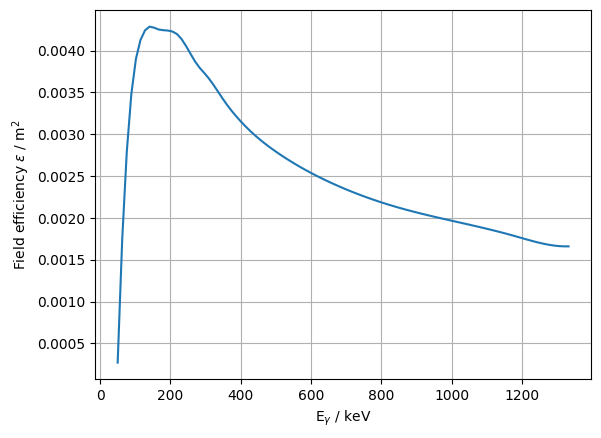

In [10]:
E = np.linspace(50, 1332, 100)
eff = get_field_efficiency('LU_HPGe_90', E)
plt.plot(E, eff)
plt.grid()
plt.xlabel("E$_\\gamma$ / keV")
plt.ylabel("Field efficiency $\\varepsilon$ / m$^2$")
plt.savefig("./plots/field_eff_hpge.png")

## 2. Angular effiency

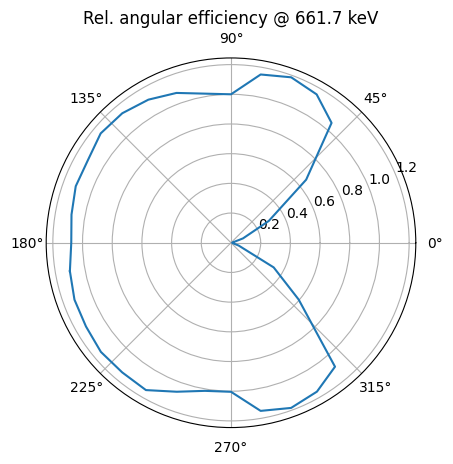

In [11]:
from pg_rad.detector.detector import load_detector
import pg_rad.plotting.result_plotter as rp

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
det = load_detector("LU_HPGe_90")
rp.ResultPlotter._draw_angular_efficiency_polar(None, ax, det, 661.67)
plt.savefig("./plots/angular_eff_hpge.png")

## Count rate alignment problem

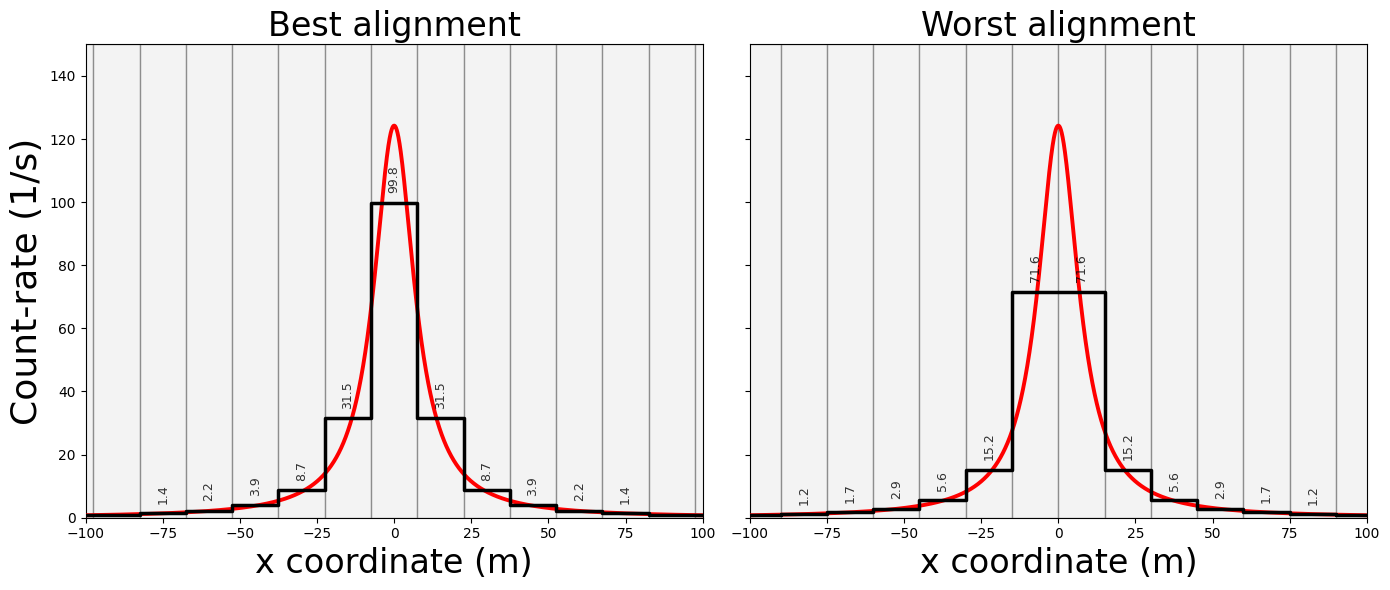

In [52]:
A, n_gamma, mu_air, epsilon = 1E5, 1.0, 0.0001, 1.0
y0 = 8.0
x_min, x_max = -100, 100
y_max = 150
bin_width, dx_fine = 15.0, 0.05

def count_rate(x):
    r = np.sqrt(x**2 + y0**2)
    return epsilon * A * n_gamma * np.exp(-mu_air * r) / (4 * np.pi * r**2)

def compute_bins(edges):
    centers = 0.5 * (edges[:-1] + edges[1:])
    avg_rates, cumulative_counts = [], []
    for x0, x1 in zip(edges[:-1], edges[1:]):
        xs = np.linspace(x0, x1, 2000)
        rates = count_rate(xs)
        avg_rates.append(np.mean(rates))
        cumulative_counts.append(np.trapezoid(rates, xs))  # Removed normalization
    return centers, np.array(avg_rates), np.array(cumulative_counts)

best_edges = np.arange(-7.5 - 20 * bin_width, 7.5 + 20 * bin_width, bin_width)
worst_edges = np.arange(-20 * bin_width, 20 * bin_width + bin_width, bin_width)
best_centers, best_rates, best_counts = compute_bins(best_edges)
worst_centers, worst_rates, worst_counts = compute_bins(worst_edges)
x_fine = np.arange(x_min, x_max + dx_fine, dx_fine)
y_fine = count_rate(x_fine)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
cases = [
    (axes[0], "Best alignment", best_edges, best_centers, best_rates, best_counts),
    (axes[1], "Worst alignment", worst_edges, worst_centers, worst_rates, worst_counts),
]

for ax, title, edges, centers, rates, counts in cases:
    for x0, x1 in zip(edges[:-1], edges[1:]):
        ax.add_patch(Rectangle((x0, 0), x1 - x0, y_max, facecolor="lightgray", edgecolor="black", linewidth=1, alpha=0.25))
    ax.plot(x_fine, y_fine, color='red', linewidth=2.8, zorder=5)
    ax.step(edges[:-1], rates, where="post", color="black", linewidth=2.5, zorder=6)
    for xc, yc, c in zip(centers, rates, counts):
        if yc > 1:
            ax.text(xc, yc + 3, f"{c/(x1-x0):.1f}", fontsize=9, rotation=90, ha="center", va="bottom", zorder=7, alpha=0.8)
    ax.set_title(title, fontsize=24)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xlabel("x coordinate (m)", fontsize=24)
#ax.grid(alpha=0.2)
axes[0].set_ylabel("Count-rate (1/s)", fontsize=26)
#plt.suptitle("Effect of acquisition-bin alignment on observed peak count-rate", fontsize=22)
plt.tight_layout()
plt.savefig('plots/mgs-source-alignment.png')

## Acquisitions along path

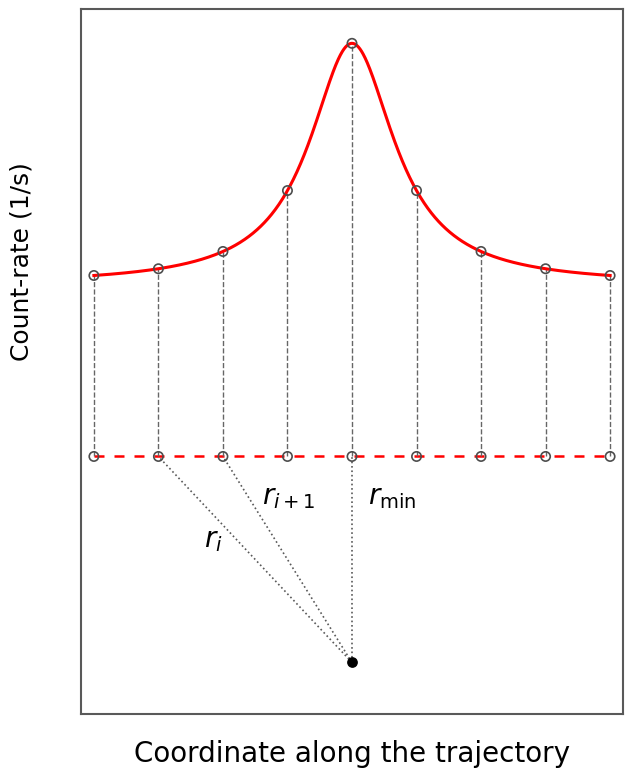

In [77]:
plt.rcParams.update({"font.size": 14, "axes.titlesize": 18, "axes.labelsize": 20, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.facecolor": "#ffffff", "figure.facecolor": "#ffffff", "axes.edgecolor": "0.3", "axes.linewidth": 1.5, "grid.color": "0.75", "grid.alpha": 0.25})

x = np.linspace(-40, 40, 9)
d = 8.0
source_x, source_y = 0.0, -12.0

def count_rate(x): return 900 / (np.sqrt(x**2 + d**2)**2)

x_fine = np.linspace(-40, 40, 1000)
y_fine = count_rate(x_fine)
y_samples = count_rate(x)

fig, ax = plt.subplots(figsize=(6.5, 8))
upper_offset = 10

ax.plot(x_fine, y_fine + upper_offset, color="red", linewidth=2.2, zorder=5)
ax.scatter(x, y_samples + upper_offset, s=45, facecolors="none", edgecolors="0.3", linewidths=1.2, zorder=6)

trajectory_y = 0
ax.plot([x.min(), x.max()], [trajectory_y, trajectory_y], linestyle=(0, (4, 4)), color="red", linewidth=1.8)
ax.scatter(x, np.full_like(x, trajectory_y), s=45, facecolors="none", edgecolors="0.3", linewidths=1.2, zorder=6)

for xi, yi in zip(x, y_samples): ax.plot([xi, xi], [trajectory_y, yi + upper_offset], linestyle="--", color="0.4", linewidth=1.0)

ax.scatter(source_x, source_y, s=45, color="black", zorder=10)

xi, ri_y = -30, trajectory_y
ax.plot([source_x, xi], [source_y, ri_y], linestyle=":", color="0.35", linewidth=1.2)
ax.plot([source_x, -20], [source_y, ri_y], linestyle=":", color="0.35", linewidth=1.2)
ax.plot([source_x, source_x], [source_y, trajectory_y], linestyle=":", color="0.35", linewidth=1.2)

ax.text(-23, -5.2, r"$r_i$", fontsize=20)
ax.text(-14, -2.7, r"$r_{i+1}$", fontsize=20)
ax.text(2.5, -2.7, r"$r_{\min}$", fontsize=20)

ax.set_xlabel("Coordinate along the trajectory", fontsize=20, labelpad=18)
ax.text(-53, upper_offset + np.max(y_fine) * 0.1, "Count-rate (1/s)", rotation=90, fontsize=18, va="center")

ax.set_xlim(-42, 42)
ax.set_ylim(-15, upper_offset + np.max(y_fine) + 2)
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values(): spine.set_linewidth(1.5); spine.set_color("0.35")

plt.tight_layout()
plt.savefig('plots/cps_example.png')

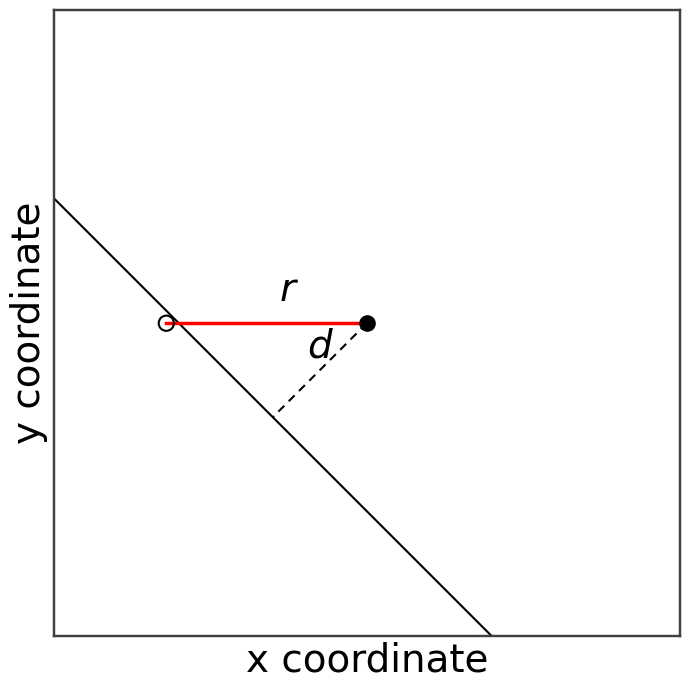

In [13]:
trajectory_example()